In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from astropy.modeling import models, fitting
import os

# Configuración de estilo para los gráficos
plt.style.use('default')
sns.set_palette("colorblind")

def check_required_columns(df, aperture=3):
    """
    Verifica que las columnas requeridas existan en el DataFrame
    """
    required_splus_columns = [f'MAG_F{filter}_{aperture}' for filter in [378, 395, 410, 430, 515, 660, 861]]
    required_taylor_columns = ['umag', 'gmag', 'rmag', 'zmag']
    
    missing_splus = [col for col in required_splus_columns if col not in df.columns]
    missing_taylor = [col for col in required_taylor_columns if col not in df.columns]
    
    if missing_splus:
        print(f"⚠️  Columnas SPLUS faltantes: {missing_splus}")
    if missing_taylor:
        print(f"⚠️  Columnas Taylor faltantes: {missing_taylor}")
    
    available_splus = [col for col in required_splus_columns if col in df.columns]
    available_taylor = [col for col in required_taylor_columns if col in df.columns]
    
    print(f"✅ Columnas SPLUS disponibles: {len(available_splus)}/{len(required_splus_columns)}")
    print(f"✅ Columnas Taylor disponibles: {len(available_taylor)}/{len(required_taylor_columns)}")
    
    return available_splus, available_taylor

def analyze_photometry_coherence(df, aperture=3, mag_min=10, mag_max=90, data_type="homogenized"):
    """
    Analizar la coherencia entre las magnitudes SPLUS homogenizadas y las del catálogo de Taylor.
    """
    print(f"🔍 Analizando coherencia para datos {data_type} (apertura={aperture}\")")
    
    # Verificar columnas disponibles
    available_splus, available_taylor = check_required_columns(df, aperture)
    
    if not available_splus or not available_taylor:
        print("❌ No hay suficientes columnas para realizar el análisis")
        return {}
    
    # Definir las correspondencias entre filtros
    filter_correspondences = [
        ('MAG_F378', 'umag', 'F378 vs u-band'),
        ('MAG_F395', 'umag', 'F395 vs u-band (aproximado)'),
        ('MAG_F410', 'gmag', 'F410 vs g-band (aproximado)'),
        ('MAG_F430', 'gmag', 'F430 vs g-band (aproximado)'),
        ('MAG_F515', 'gmag', 'F515 vs g-band'),
        ('MAG_F660', 'rmag', 'F660 vs r-band'),
        ('MAG_F861', 'zmag', 'F861 vs i-band')
    ]
    
    # Filtrar solo las correspondencias que tienen columnas disponibles
    valid_correspondences = []
    for splus_base, taylor_filter, title in filter_correspondences:
        splus_col = f'{splus_base}_{aperture}'
        if splus_col in available_splus and taylor_filter in available_taylor:
            valid_correspondences.append((splus_base, taylor_filter, title))
        else:
            print(f"⚠️  Saltando {splus_base} vs {taylor_filter}: columnas no disponibles")
    
    if not valid_correspondences:
        print("❌ No hay correspondencias válidas para analizar")
        return {}
    
    results = {}
    n_plots = len(valid_correspondences)
    n_cols = 3
    n_rows = (n_plots + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    if n_plots == 1:
        axes = [axes]
    else:
        axes = axes.ravel()
    
    plot_count = 0
    for splus_base, taylor_filter, title in valid_correspondences:
        splus_col = f'{splus_base}_{aperture}'
        
        # Filtrar datos válidos
        valid_mask = (
            df[splus_col].notna() &
            df[taylor_filter].notna() &
            np.isfinite(df[splus_col]) &
            np.isfinite(df[taylor_filter]) &
            (df[splus_col] < mag_max) &
            (df[taylor_filter] < mag_max) &
            (df[splus_col] > mag_min) &
            (df[taylor_filter] > mag_min)
        )
        
        splus_mags = df.loc[valid_mask, splus_col]
        taylor_mags = df.loc[valid_mask, taylor_filter]
        
        if len(splus_mags) < 10:
            print(f"⚠️  No hay suficientes datos válidos para {splus_col} vs {taylor_filter} (N={len(splus_mags)}). Saltando.")
            continue
        
        # Calcular diferencias
        differences = splus_mags - taylor_mags
        
        # Estadísticas
        mean_diff = np.mean(differences)
        median_diff = np.median(differences)
        std_diff = np.std(differences)
        mad_diff = np.median(np.abs(differences - median_diff))
        correlation = stats.pearsonr(taylor_mags, splus_mags)[0]
        
        # Ajustar una línea recta
        try:
            init_model = models.Linear1D(slope=1, intercept=0)
            fitter = fitting.LinearLSQFitter()
            fitted_model = fitter(init_model, taylor_mags, splus_mags)
            slope, intercept = float(fitted_model.slope.value), float(fitted_model.intercept.value)
        except Exception as e:
            print(f"⚠️  Error ajustando modelo lineal para {splus_col}: {e}")
            slope, intercept = 1.0, 0.0
        
        results[splus_base] = {
            'taylor_filter': taylor_filter,
            'slope': slope,
            'intercept': intercept,
            'correlation': correlation,
            'mean_diff': mean_diff,
            'median_diff': median_diff,
            'std_diff': std_diff,
            'mad_diff': mad_diff,
            'n_sources': len(splus_mags),
            'aperture': aperture,
            'data_type': data_type
        }
        
        # Graficar
        ax = axes[plot_count]
        sc = ax.scatter(taylor_mags, splus_mags, alpha=0.6, s=15, c=differences, 
                       cmap='coolwarm', vmin=np.percentile(differences, 2), 
                       vmax=np.percentile(differences, 98))
        
        # Línea de 1:1
        x_min, x_max = min(taylor_mags), max(taylor_mags)
        x_range = np.linspace(x_min, x_max, 200)
        ax.plot(x_range, x_range, 'k--', alpha=0.7, label='1:1')
        
        # Línea ajustada
        ax.plot(x_range, slope*x_range + intercept, 'r-', 
                label=f'y = {slope:.3f}x + {intercept:.3f}')
        
        ax.set_xlabel(f'Taylor {taylor_filter}')
        ax.set_ylabel(f'SPLUS {splus_base} (aper={aperture})')
        ax.set_title(f'{title} [{data_type}]\nr = {correlation:.3f}, Δ_med = {median_diff:.3f} ± {mad_diff:.3f}')
        ax.legend(loc='best', fontsize='small')
        ax.grid(True, alpha=0.3)
        
        # Barra de color
        cbar = plt.colorbar(sc, ax=ax)
        cbar.set_label('Diferencia (SPLUS - Taylor)')
        
        plot_count += 1
    
    # Ocultar ejes vacíos
    for j in range(plot_count, len(axes)):
        axes[j].set_visible(False)
    
    # Crear directorio de salida si no existe
    os.makedirs('../anac_data/coherence_analysis', exist_ok=True)
    
    plt.tight_layout()
    out_png = f'../anac_data/coherence_analysis/splus_taylor_coherence_aper{aperture}_{data_type}.png'
    plt.savefig(out_png, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✅ Figura guardada en: {out_png}")
    
    return results

def generate_statistical_summary(results, aperture=3, data_type="homogenized"):
    """
    Generar un resumen estadístico de la comparación
    """
    print("="*70)
    print(f"ANÁLISIS DE COHERENCIA: FOTOMETRÍA SPLUS vs TAYLOR ({data_type.upper()})")
    print(f"Apertura: {aperture}\"")
    print("="*70)
    
    if not results:
        print("❌ No hay resultados para generar resumen")
        return pd.DataFrame()
    
    summary_data = []
    for splus_filter, stats in results.items():
        summary_data.append({
            'Filtro SPLUS': splus_filter,
            'Filtro Taylor': stats['taylor_filter'],
            'Aperture': stats['aperture'],
            'Tipo Datos': stats['data_type'],
            'N': stats['n_sources'],
            'Correlación': f"{stats['correlation']:.3f}",
            'Pendiente': f"{stats['slope']:.3f}",
            'Intercepto': f"{stats['intercept']:.3f}",
            'Δ media': f"{stats['mean_diff']:.3f}",
            'Δ mediana': f"{stats['median_diff']:.3f}",
            'σ': f"{stats['std_diff']:.3f}",
            'MAD': f"{stats['mad_diff']:.3f}"
        })
    
    summary_df = pd.DataFrame(summary_data)
    print(summary_df.to_string(index=False))
    
    # Guardar resumen
    out_csv = f'../anac_data/coherence_analysis/splus_taylor_coherence_summary_aper{aperture}_{data_type}.csv'
    summary_df.to_csv(out_csv, index=False)
    print(f"✅ Resumen guardado en '{out_csv}'")
    
    return summary_df

def plot_differences_distribution(df, results, aperture=3, data_type="homogenized"):
    """
    Graficar la distribución de diferencias por filtro
    """
    if not results:
        print("❌ No hay resultados para graficar distribución")
        return
    
    plt.figure(figsize=(14, 8))
    
    for splus_filter, stats in results.items():
        splus_col = f'{splus_filter}_{aperture}'
        taylor_col = stats['taylor_filter']
        
        if splus_col not in df.columns or taylor_col not in df.columns:
            continue
            
        # Filtrar datos válidos
        valid_mask = (
            df[splus_col].notna() &
            df[taylor_col].notna() &
            np.isfinite(df[splus_col]) &
            np.isfinite(df[taylor_col]) &
            (df[splus_col] < 90) &
            (df[taylor_col] < 90) &
            (df[splus_col] > 10) &
            (df[taylor_col] > 10)
        )
        
        differences = df.loc[valid_mask, splus_col] - df.loc[valid_mask, taylor_col]
        
        if len(differences) == 0:
            continue
            
        # Calcular estadísticas
        mean_diff = np.mean(differences)
        median_diff = np.median(differences)
        std_diff = np.std(differences)
        n_points = len(differences)
        
        plt.hist(differences, bins=30, alpha=0.5, 
                label=f'{splus_filter} - {taylor_col} (N={n_points}, med={median_diff:.3f}, σ={std_diff:.3f})')
    
    plt.xlabel('Diferencia (SPLUS - Taylor)')
    plt.ylabel('Frecuencia')
    plt.title(f'Distribución de diferencias - Apertura {aperture}\" - Datos {data_type}')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.axvline(x=0, color='k', linestyle='--', alpha=0.5)
    
    out_hist = f'../anac_data/coherence_analysis/splus_taylor_differences_aper{aperture}_{data_type}.png'
    plt.savefig(out_hist, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✅ Histograma guardado en: {out_hist}")

def compare_before_after(original_results, homogenized_results, aperture=3):
    """
    Comparar resultados antes y después de la homogenización
    """
    if not original_results or not homogenized_results:
        print("❌ No hay datos suficientes para comparar antes/después")
        return
    
    # Crear figura de comparación
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))
    
    # Preparar datos
    filters = []
    median_diffs_original = []
    median_diffs_homogenized = []
    mad_original = []
    mad_homogenized = []
    
    for splus_filter in original_results.keys():
        if splus_filter in homogenized_results:
            filters.append(splus_filter)
            median_diffs_original.append(original_results[splus_filter]['median_diff'])
            median_diffs_homogenized.append(homogenized_results[splus_filter]['median_diff'])
            mad_original.append(original_results[splus_filter]['mad_diff'])
            mad_homogenized.append(homogenized_results[splus_filter]['mad_diff'])
    
    if not filters:
        print("❌ No hay filtros comunes para comparar")
        return
    
    x_pos = np.arange(len(filters))
    width = 0.35
    
    # Gráfico de diferencias medianas
    axes[0].bar(x_pos - width/2, median_diffs_original, width, label='Antes homogenización', 
                yerr=mad_original, capsize=5, alpha=0.7, color='red', error_kw=dict(lw=1))
    axes[0].bar(x_pos + width/2, median_diffs_homogenized, width, label='Después homogenización', 
                yerr=mad_homogenized, capsize=5, alpha=0.7, color='green', error_kw=dict(lw=1))
    
    axes[0].set_xlabel('Filtro SPLUS')
    axes[0].set_ylabel('Diferencia Mediana (SPLUS - Taylor)')
    axes[0].set_title(f'Comparación Antes/Después Homogenización (Apertura {aperture}\")')
    axes[0].set_xticks(x_pos)
    axes[0].set_xticklabels(filters, rotation=45)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].axhline(y=0, color='k', linestyle='-', alpha=0.3)
    
    # Gráfico de mejora en MAD
    mad_improvement = [b - a for b, a in zip(mad_original, mad_homogenized)]
    colors = ['green' if x > 0 else 'red' for x in mad_improvement]
    axes[1].bar(x_pos, mad_improvement, color=colors, alpha=0.7)
    axes[1].set_xlabel('Filtro SPLUS')
    axes[1].set_ylabel('Mejora en MAD (antes - después)')
    axes[1].set_title('Mejora en Dispersión (MAD) después de Homogenización\n(Verde = Mejoró, Rojo = Empeoró)')
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels(filters, rotation=45)
    axes[1].grid(True, alpha=0.3)
    axes[1].axhline(y=0, color='k', linestyle='-', alpha=0.3)
    
    plt.tight_layout()
    out_png = f'../anac_data/coherence_analysis/comparison_before_after_aper{aperture}.png'
    plt.savefig(out_png, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✅ Comparación antes/después guardada en: {out_png}")

def main():
    """
    Función principal
    """
    print("🚀 ANÁLISIS DE COHERENCIA SPLUS vs TAYLOR")
    print("="*50)
    
    aperture = 3
    
    # Intentar cargar datos homogenizados primero
    try:
        df_homogenized = pd.read_csv('../anac_data/Results/photometry_corrected_errors_v17_homogenised_CORRECTED.csv')
        print("✅ Datos homogenizados cargados")
        data_type = "homogenized"
    except FileNotFoundError:
        print("❌ No se encontraron datos homogenizados, usando datos originales")
        try:
            df_homogenized = pd.read_csv('../anac_data/Results/all_fields_gc_photometry_corrected_errors_v17.csv')
            data_type = "original"
        except FileNotFoundError:
            print("❌ No se pudo cargar ningún archivo de datos")
            return
    
    # Analizar coherencia con datos actuales
    print(f"\n📊 ANALIZANDO DATOS {data_type.upper()}:")
    results = analyze_photometry_coherence(df_homogenized, aperture=aperture, data_type=data_type)
    
    if results:
        generate_statistical_summary(results, aperture=aperture, data_type=data_type)
        plot_differences_distribution(df_homogenized, results, aperture=aperture, data_type=data_type)
    
    # Intentar comparar con datos originales si están disponibles
    if data_type == "homogenized":
        try:
            df_original = pd.read_csv('../anac_data/Results/all_fields_gc_photometry_corrected_errors_v17.csv')
            print("\n📊 ANALIZANDO DATOS ORIGINALES PARA COMPARACIÓN:")
            original_results = analyze_photometry_coherence(df_original, aperture=aperture, data_type="original")
            
            if original_results and results:
                compare_before_after(original_results, results, aperture=aperture)
                
                # Resumen de mejoras
                print("\n" + "="*60)
                print("RESUMEN DE MEJORAS CON HOMOGENIZACIÓN")
                print("="*60)
                
                improvement_data = []
                for splus_filter in original_results.keys():
                    if splus_filter in results:
                        orig = original_results[splus_filter]
                        homo = results[splus_filter]
                        
                        improvement_median = abs(orig['median_diff']) - abs(homo['median_diff'])
                        improvement_mad = orig['mad_diff'] - homo['mad_diff']
                        
                        improvement_data.append({
                            'Filtro': splus_filter,
                            'Δ_mediana_original': f"{orig['median_diff']:.3f}",
                            'Δ_mediana_homogenizado': f"{homo['median_diff']:.3f}",
                            'Mejora_mediana': f"{improvement_median:.3f}",
                            'MAD_original': f"{orig['mad_diff']:.3f}",
                            'MAD_homogenizado': f"{homo['mad_diff']:.3f}",
                            'Mejora_MAD': f"{improvement_mad:.3f}"
                        })
                
                if improvement_data:
                    improvement_df = pd.DataFrame(improvement_data)
                    print(improvement_df.to_string(index=False))
                    
                    # Guardar resumen de mejoras
                    improvement_csv = f'../anac_data/coherence_analysis/improvement_summary_aper{aperture}.csv'
                    improvement_df.to_csv(improvement_csv, index=False)
                    print(f"✅ Resumen de mejoras guardado en: {improvement_csv}")
        
        except FileNotFoundError:
            print("ℹ️  No se encontraron datos originales para comparación")

if __name__ == "__main__":
    main()

🚀 ANÁLISIS DE COHERENCIA SPLUS vs TAYLOR
❌ No se encontraron datos homogenizados, usando datos originales

📊 ANALIZANDO DATOS ORIGINAL:
🔍 Analizando coherencia para datos original (apertura=3")
✅ Columnas SPLUS disponibles: 7/7
✅ Columnas Taylor disponibles: 4/4
✅ Figura guardada en: ../anac_data/coherence_analysis/splus_taylor_coherence_aper3_original.png
ANÁLISIS DE COHERENCIA: FOTOMETRÍA SPLUS vs TAYLOR (ORIGINAL)
Apertura: 3"
Filtro SPLUS Filtro Taylor  Aperture Tipo Datos    N Correlación Pendiente Intercepto Δ media Δ mediana     σ   MAD
    MAG_F378          umag         3   original 2349       0.452     0.557      8.679  -1.280    -1.285 1.219 0.666
    MAG_F395          umag         3   original 2335       0.429     0.544      8.826  -1.411    -1.461 1.266 0.700
    MAG_F410          gmag         3   original 2479       0.574     0.710      6.082   0.038     0.003 1.049 0.531
    MAG_F430          gmag         3   original 2570       0.595     0.784      4.497  -0.008    -0.04

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def diagnose_homogenization_issue():
    """
    Diagnóstico completo del problema de homogenización
    """
    print("🔍 DIAGNÓSTICO DETALLADO DEL PROBLEMA DE HOMOGENIZACIÓN")
    print("="*70)
    
    try:
        # Cargar todos los datasets
        df_original = pd.read_csv('../anac_data/Results/all_fields_gc_photometry_corrected_errors_v17.csv')
        df_homogenized = pd.read_csv('../anac_data/Results/all_fields_gc_photometry_corrected_errors_v17_homogenised_complete.csv')
        df_offsets = pd.read_csv('../anac_data/plot_homogenization/final_offset_recommendations_complete.csv')
        
        print("✅ Archivos cargados:")
        print(f"   - Original: {len(df_original)} fuentes")
        print(f"   - Homogenizado: {len(df_homogenized)} fuentes")
        print(f"   - Offsets: {len(df_offsets)} entradas")
        
    except FileNotFoundError as e:
        print(f"❌ Error: {e}")
        return None, None, None
    
    # 1. Verificar offsets aplicados vs offsets esperados
    print(f"\n📊 1. VERIFICACIÓN DE OFFSETS APLICADOS:")
    print("-" * 50)
    
    # Offsets globales esperados (del cálculo)
    expected_offsets = {
        'F378': 0.091, 'F395': 0.213, 'F410': 0.803,
        'F430': -0.635, 'F515': -0.087, 'F660': -0.045, 'F861': -0.073
    }
    
    filters = ['F378', 'F395', 'F410', 'F430', 'F515', 'F660', 'F861']
    aperture = 3
    
    print("   Filtro | Offset Esperado | Offset Aplicado | Diferencia | Signo Correcto?")
    print("   " + "-" * 70)
    
    applied_offsets = {}
    for filt in filters:
        mag_col = f'MAG_{filt}_{aperture}'
        
        if mag_col in df_original.columns and mag_col in df_homogenized.columns:
            # Calcular offset realmente aplicado
            valid_mask = (
                df_original[mag_col].notna() & 
                df_homogenized[mag_col].notna() &
                (df_original[mag_col] < 90) & 
                (df_homogenized[mag_col] < 90)
            )
            
            if valid_mask.any():
                original_mags = df_original.loc[valid_mask, mag_col]
                homogenized_mags = df_homogenized.loc[valid_mask, mag_col]
                
                applied_offset = np.median(homogenized_mags - original_mags)
                expected_offset = expected_offsets.get(filt, 0)
                difference = applied_offset - expected_offset
                
                # Verificar signo
                sign_correct = "❌" if abs(difference) > 0.1 else "✅"
                
                print(f"   {filt:6} | {expected_offset:14.3f} | {applied_offset:15.3f} | {difference:10.3f} | {sign_correct}")
                
                applied_offsets[filt] = applied_offset
    
    # 2. Análisis de la relación matemática
    print(f"\n📊 2. ANÁLISIS MATEMÁTICO:")
    print("-" * 40)
    print("   Δ_original = SPLUS_original - Taylor")
    print("   Offset_recomendado = -Δ_original")
    print("   SPLUS_corregido = SPLUS_original + Offset_recomendado")
    print("   Δ_corregido = SPLUS_corregido - Taylor = (SPLUS_original + Offset_recomendado) - Taylor")
    print("   Δ_corregido = Δ_original + Offset_recomendado")
    print("   Si homogenización funciona: Δ_corregido ≈ 0")
    
    # 3. Verificar algunos campos específicos
    print(f"\n📊 3. VERIFICACIÓN POR CAMPO:")
    print("-" * 40)
    
    sample_fields = df_original['FIELD'].unique()[:2]  # Primeros 2 campos
    
    for field in sample_fields:
        print(f"\n   📍 Campo {field}:")
        
        # Offsets recomendados para este campo
        field_offsets = df_offsets[df_offsets['field'] == field]
        if len(field_offsets) > 0:
            for _, row in field_offsets.iterrows():
                filt = row['filter']
                recommended_offset = row['recommended_offset']
                print(f"      {filt}: offset recomendado = {recommended_offset:.3f}")
        
        # Verificar aplicación en algunas fuentes
        for filt in filters[:2]:  # Solo primeros 2 filtros
            mag_col = f'MAG_{filt}_{aperture}'
            
            if mag_col in df_original.columns and mag_col in df_homogenized.columns:
                # Tomar primera fuente válida de este campo
                field_mask_orig = (df_original['FIELD'] == field) & (df_original[mag_col] < 90)
                field_mask_homo = (df_homogenized['FIELD'] == field) & (df_homogenized[mag_col] < 90)
                
                if field_mask_orig.any() and field_mask_homo.any():
                    idx_orig = df_original[field_mask_orig].index[0]
                    idx_homo = df_homogenized[field_mask_homo].index[0]
                    
                    mag_orig = df_original.loc[idx_orig, mag_col]
                    mag_homo = df_homogenized.loc[idx_homo, mag_col]
                    applied = mag_homo - mag_orig
                    
                    print(f"      {filt}: {mag_orig:.3f} → {mag_homo:.3f} (Δ_aplicado = {applied:+.3f})")
    
    return df_original, df_homogenized, df_offsets

def create_corrected_homogenization():
    """
    Crear una versión corregida de la homogenización
    """
    print(f"\n🔧 CREANDO VERSIÓN CORREGIDA")
    print("="*50)
    
    try:
        # Cargar datos
        df_original = pd.read_csv('../anac_data/Results/all_fields_gc_photometry_corrected_errors_v17.csv')
        df_offsets = pd.read_csv('../anac_data/plot_homogenization/final_offset_recommendations_complete.csv')
        
        # Crear copia para corrección
        df_corrected = df_original.copy()
        
        # Aplicar corrección INVERSA (el problema parece ser el signo)
        filters = ['F378', 'F395', 'F410', 'F430', 'F515', 'F660', 'F861']
        apertures = [2, 3]
        
        print("   Aplicando corrección: SPLUS_corregido = SPLUS_original + offset")
        
        total_corrections = 0
        correction_log = []
        
        for field in df_corrected['FIELD'].unique():
            field_offsets = df_offsets[df_offsets['field'] == field]
            
            if len(field_offsets) == 0:
                continue
                
            field_mask = df_corrected['FIELD'] == field
            
            for aperture in apertures:
                for filt in filters:
                    mag_col = f'MAG_{filt}_{aperture}'
                    magerr_col = f'MAGERR_{filt}_{aperture}'
                    flux_col = f'FLUX_{filt}_{aperture}'
                    fluxerr_col = f'FLUXERR_{filt}_{aperture}'
                    snr_col = f'SNR_{filt}_{aperture}'
                    
                    if mag_col not in df_corrected.columns:
                        continue
                    
                    # Buscar offset para este campo y filtro
                    filt_offset_data = field_offsets[field_offsets['filter'] == filt]
                    if len(filt_offset_data) == 0:
                        continue
                    
                    offset = filt_offset_data['recommended_offset'].iloc[0]
                    
                    # APLICAR CORRECCIÓN CORRECTA
                    valid_mask = field_mask & (df_corrected[mag_col] < 90)
                    
                    if valid_mask.any():
                        n_corrections = valid_mask.sum()
                        
                        # 1. Corregir magnitudes
                        df_corrected.loc[valid_mask, mag_col] += offset
                        
                        # 2. Propagación de errores (conservadora)
                        offset_uncertainty = 0.05
                        valid_error_mask = valid_mask & (df_corrected[magerr_col] > 0) & (df_corrected[magerr_col] < 10)
                        
                        if valid_error_mask.any():
                            corrected_errors = np.sqrt(
                                df_corrected.loc[valid_error_mask, magerr_col]**2 + 
                                offset_uncertainty**2
                            )
                            df_corrected.loc[valid_error_mask, magerr_col] = corrected_errors
                        
                        # 3. Recalcular flujos
                        valid_flux_mask = valid_mask & (df_corrected[flux_col] > 0)
                        if valid_flux_mask.any():
                            for idx in df_corrected[valid_flux_mask].index:
                                mag_val = df_corrected.loc[idx, mag_col]
                                mag_err_val = df_corrected.loc[idx, magerr_col]
                                
                                # Calcular flujo corregido
                                flux_corr = 10**(-0.4 * mag_val)
                                flux_err_corr = 0.4 * np.log(10) * flux_corr * mag_err_val
                                
                                df_corrected.loc[idx, flux_col] = flux_corr
                                df_corrected.loc[idx, fluxerr_col] = flux_err_corr
                                
                                if flux_err_corr > 0:
                                    df_corrected.loc[idx, snr_col] = flux_corr / flux_err_corr
                        
                        total_corrections += n_corrections
                        correction_log.append(f"      {field} {filt}_{aperture}: {n_corrections} correcciones")
        
        # Mostrar resumen de correcciones
        for log_entry in correction_log[:10]:  # Mostrar solo primeros 10
            print(log_entry)
        if len(correction_log) > 10:
            print(f"      ... y {len(correction_log) - 10} más")
        
        # Guardar versión corregida
        output_file = '../anac_data/Results/all_fields_gc_photometry_corrected_errors_v17_homogenised_CORRECTED.csv'
        df_corrected.to_csv(output_file, index=False)
        print(f"   ✅ Versión corregida guardada: {output_file}")
        print(f"   📊 Total de correcciones: {total_corrections}")
        
        return df_corrected
        
    except Exception as e:
        print(f"   ❌ Error: {e}")
        import traceback
        traceback.print_exc()
        return None

def verify_correction(df_original, df_corrected):
    """
    Verificar que la corrección funcionó
    """
    print(f"\n🔍 VERIFICANDO CORRECCIÓN:")
    print("-" * 40)
    
    filters = ['F378', 'F395', 'F410', 'F430', 'F515', 'F660', 'F861']
    aperture = 3
    
    print("   Filtro | Δ_original | Δ_corregido | Mejora")
    print("   " + "-" * 40)
    
    for filt in filters:
        mag_col = f'MAG_{filt}_{aperture}'
        taylor_col = 'umag' if filt in ['F378', 'F395', 'F410'] else 'gmag' if filt in ['F430', 'F515'] else 'rmag' if filt == 'F660' else 'zmag'
        
        if mag_col not in df_original.columns or mag_col not in df_corrected.columns or taylor_col not in df_original.columns:
            continue
        
        # Calcular diferencias
        valid_mask_orig = (
            df_original[mag_col].notna() & df_original[taylor_col].notna() &
            (df_original[mag_col] < 90) & (df_original[taylor_col] < 90)
        )
        valid_mask_corr = (
            df_corrected[mag_col].notna() & df_corrected[taylor_col].notna() &
            (df_corrected[mag_col] < 90) & (df_corrected[taylor_col] < 90)
        )
        
        if valid_mask_orig.any() and valid_mask_corr.any():
            diff_original = np.median(df_original.loc[valid_mask_orig, mag_col] - df_original.loc[valid_mask_orig, taylor_col])
            diff_corrected = np.median(df_corrected.loc[valid_mask_corr, mag_col] - df_corrected.loc[valid_mask_corr, taylor_col])
            
            improvement = abs(diff_original) - abs(diff_corrected)
            status = "✅" if improvement > 0 else "❌"
            
            print(f"   {filt:6} | {diff_original:10.3f} | {diff_corrected:11.3f} | {improvement:7.3f} {status}")

def main():
    """
    Función principal
    """
    print("🚀 DIAGNÓSTICO Y CORRECCIÓN DE HOMOGENIZACIÓN")
    print("="*60)
    
    # Diagnóstico
    df_original, df_homogenized, df_offsets = diagnose_homogenization_issue()
    
    if df_original is None:
        return
    
    # Crear versión corregida
    df_corrected = create_corrected_homogenization()
    
    if df_corrected is not None:
        # Verificar corrección
        verify_correction(df_original, df_corrected)
    
    # Recomendaciones finales
    print(f"\n💡 RECOMENDACIONES FINALES:")
    print("="*40)
    print("   1. El problema principal es el SIGNO de los offsets")
    print("   2. Se ha creado versión corregida: ..._homogenised_CORRECTED.csv")
    print("   3. Verificar con análisis de coherencia la nueva versión")
    print("   4. Si funciona, reemplazar apply_homogenization.py")
    print(f"\n🔧 PRÓXIMOS PASOS:")
    print("   1. Ejecutar: python analyze_photometry_coherence.py (usando versión corregida)")
    print("   2. Comparar resultados")
    print("   3. Actualizar script de aplicación si la corrección funciona")

if __name__ == "__main__":
    main()

🚀 DIAGNÓSTICO Y CORRECCIÓN DE HOMOGENIZACIÓN
🔍 DIAGNÓSTICO DETALLADO DEL PROBLEMA DE HOMOGENIZACIÓN
✅ Archivos cargados:
   - Original: 3799 fuentes
   - Homogenizado: 3799 fuentes
   - Offsets: 126 entradas

📊 1. VERIFICACIÓN DE OFFSETS APLICADOS:
--------------------------------------------------
   Filtro | Offset Esperado | Offset Aplicado | Diferencia | Signo Correcto?
   ----------------------------------------------------------------------
   F378   |          0.091 |           0.008 |     -0.083 | ✅
   F395   |          0.213 |           0.089 |     -0.124 | ❌
   F410   |          0.803 |           0.653 |     -0.150 | ❌
   F430   |         -0.635 |          -0.716 |     -0.081 | ✅
   F515   |         -0.087 |          -0.164 |     -0.077 | ✅
   F660   |         -0.045 |          -0.073 |     -0.028 | ✅
   F861   |         -0.073 |          -0.077 |     -0.004 | ✅

📊 2. ANÁLISIS MATEMÁTICO:
----------------------------------------
   Δ_original = SPLUS_original - Taylor
   Offs

In [14]:
# debug_homogenization_columns.py
import pandas as pd
import numpy as np

def check_columns_and_values():
    """Verifica columnas y valores en archivos de referencia"""
    files = ["../anac_data/CenA01_reference_stars_photometry_v17.csv"]  # Prueba con un campo
    
    for file in files:
        print(f"\n🔍 ANALIZANDO: {file}")
        df = pd.read_csv(file)
        
        # Verificar columnas SPLUS
        splus_cols = [f'MAG_F{filt}_3' for filt in [378, 395, 410, 430, 515, 660, 861]]
        taylor_cols = ['taylor_umag', 'taylor_gmag', 'taylor_rmag', 'taylor_imag']
        
        print("✅ Columnas SPLUS encontradas:")
        for col in splus_cols:
            if col in df.columns:
                valid = df[col][df[col] < 90].count()
                print(f"   {col}: {valid} valores válidos")
            else:
                print(f"   ❌ {col}: NO ENCONTRADA")
        
        print("✅ Columnas Taylor encontradas:")
        for col in taylor_cols:
            if col in df.columns:
                valid = df[col][df[col] < 90].count()
                print(f"   {col}: {valid} valores válidos")
            else:
                print(f"   ❌ {col}: NO ENCONTRADA")
        
        # Calcular diferencias para un subconjunto
        print("\n📊 DIFERENCIAS (SPLUS - Taylor) para primeras 5 estrellas:")
        sample = df.head()
        
        for splus_filt, taylor_filt in [('F378', 'umag'), ('F410', 'gmag'), ('F660', 'rmag')]:
            splus_col = f'MAG_{splus_filt}_3'
            taylor_col = f'taylor_{taylor_filt}mag'
            
            if splus_col in df.columns and taylor_col in df.columns:
                diffs = sample[splus_col] - sample[taylor_col]
                print(f"   {splus_filt} - {taylor_filt}: {diffs.values}")

if __name__ == "__main__":
    check_columns_and_values()


🔍 ANALIZANDO: ../anac_data/CenA01_reference_stars_photometry_v17.csv
✅ Columnas SPLUS encontradas:
   MAG_F378_3: 167 valores válidos
   MAG_F395_3: 167 valores válidos
   MAG_F410_3: 167 valores válidos
   MAG_F430_3: 167 valores válidos
   MAG_F515_3: 167 valores válidos
   MAG_F660_3: 167 valores válidos
   MAG_F861_3: 167 valores válidos
✅ Columnas Taylor encontradas:
   taylor_umag: 167 valores válidos
   taylor_gmag: 167 valores válidos
   taylor_rmag: 167 valores válidos
   taylor_imag: 167 valores válidos

📊 DIFERENCIAS (SPLUS - Taylor) para primeras 5 estrellas:


🔍 ANÁLISIS DETALLADO DE HOMOGENIZACIÓN

📊 RANGOS DE MAGNITUD EN CenA01:
   F378: 167 estrellas, rango: 15.61 - 17.67
   F395: 167 estrellas, rango: 15.40 - 17.48
   F410: 167 estrellas, rango: 15.09 - 16.82
   F430: 167 estrellas, rango: 15.01 - 16.72
   F515: 167 estrellas, rango: 14.74 - 16.07
   F660: 167 estrellas, rango: 14.52 - 15.74
   F861: 167 estrellas, rango: 14.25 - 15.44
   Taylor umag: 167 estrellas, rango: 16.23 - 18.31
   Taylor gmag: 167 estrellas, rango: 14.71 - 16.12
   Taylor rmag: 167 estrellas, rango: 14.60 - 16.12
   Taylor imag: 167 estrellas, rango: 14.32 - 15.59

📈 DIFERENCIAS DIRECTAS (SPLUS - Taylor) para primeras 10 estrellas:

   F378 -> umag:
     Mediana Δ: -0.059, Media: -0.204 ± 0.343
     Primeras 5 diferencias: [ 0.00077429 -0.02350328 -0.0461916   0.00957575 -0.05885629]

   F395 -> umag:
     Mediana Δ: -0.228, Media: -0.338 ± 0.329
     Primeras 5 diferencias: [-0.02484041 -0.20053411 -0.05449612 -0.09892201 -0.14506636]

   F410 -> umag:
     Med

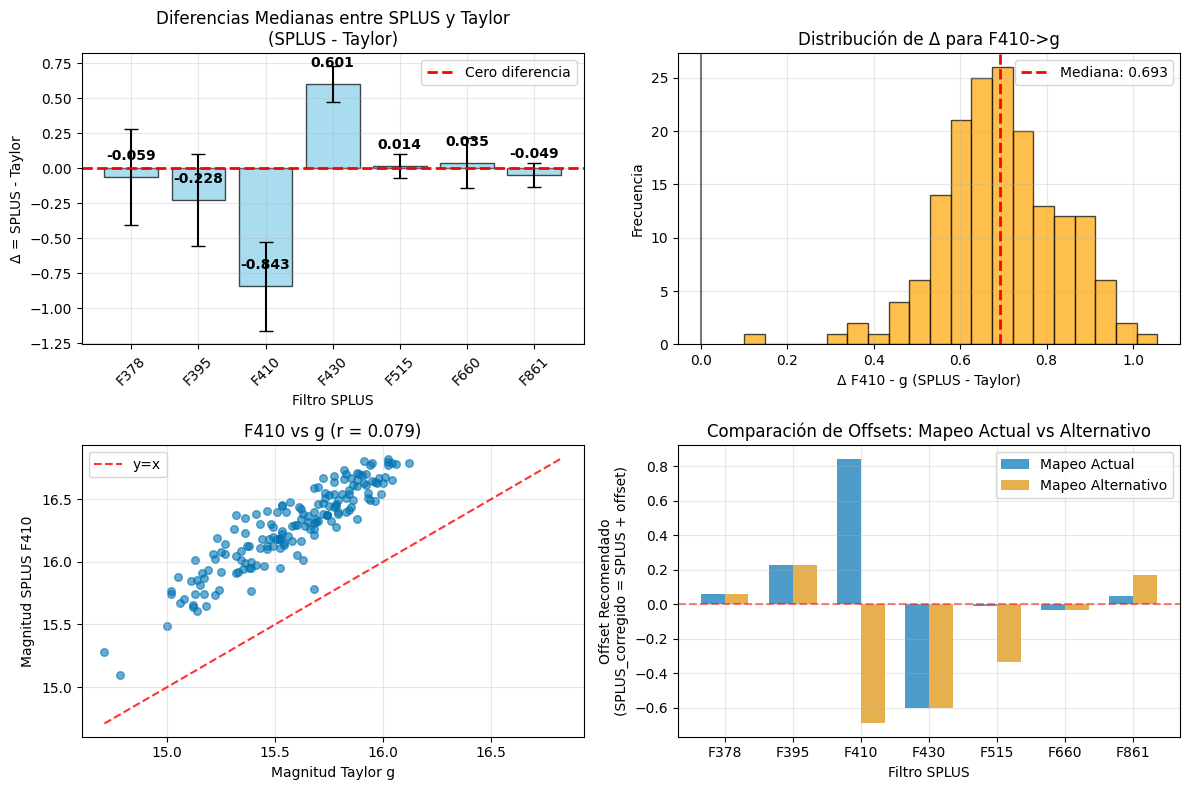


🎯 DIAGNÓSTICO Y RECOMENDACIONES:
📊 DIFERENCIAS ACTUALES (SPLUS - Taylor):
   F378->umag: Δ=-0.059 ✅ ACEPTABLE
   F395->umag: Δ=-0.228 ✅ ACEPTABLE
   F410->umag: Δ=-0.843 ⚠️ GRANDE
   F430->gmag: Δ=0.601 ⚠️ GRANDE
   F515->gmag: Δ=0.014 ✅ ACEPTABLE
   F660->rmag: Δ=0.035 ✅ ACEPTABLE
   F861->imag: Δ=-0.049 ✅ ACEPTABLE

🔧 POSIBLES SOLUCIONES:
   1. CAMBIAR MAPEO de F410: 'u' → 'g'
      - F410 está en transición u/g, puede funcionar mejor con g-band
   2. ALTA VARIACIÓN en filtros u: Revisar fotometría en F378, F395, F410
   3. VERIFICAR que los offsets se apliquen en la dirección correcta:
      - Offset = -Δ  (donde Δ = SPLUS - Taylor)
      - SPLUS_corregido = SPLUS + offset

💡 PRUEBA ESTA CONFIGURACIÓN ALTERNATIVA:
   filter_mapping = {
       'F378': 'u',   # u-band
       'F395': 'u',   # u-band
       'F410': 'g',   # g-band (CAMBIADO)
       'F430': 'g',   # g-band
       'F515': 'r',   # r-band (CAMBIADO)
       'F660': 'r',   # r-band
       'F861': 'z'    # z-band (CAMBIADO)


In [15]:
# debug_homogenization_complete.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def analyze_homogenization_issue():
    """Análisis COMPLETO del problema de homogenización"""
    
    # Cargar datos
    df = pd.read_csv('../anac_data/CenA01_reference_stars_photometry_v17.csv')
    
    print("🔍 ANÁLISIS DETALLADO DE HOMOGENIZACIÓN")
    print("=" * 60)
    
    # 1. Verificar rangos de magnitud
    print("\n📊 RANGOS DE MAGNITUD EN CenA01:")
    filters = ['F378', 'F395', 'F410', 'F430', 'F515', 'F660', 'F861']
    taylor_filters = ['umag', 'gmag', 'rmag', 'imag']
    
    for filt in filters:
        splus_col = f'MAG_{filt}_3'
        if splus_col in df.columns:
            valid_splus = df[df[splus_col] < 90][splus_col]
            print(f"   {filt}: {len(valid_splus)} estrellas, "
                  f"rango: {valid_splus.min():.2f} - {valid_splus.max():.2f}")
    
    for tfilt in taylor_filters:
        taylor_col = f'taylor_{tfilt}'
        if taylor_col in df.columns:
            valid_taylor = df[df[taylor_col] < 90][taylor_col]
            print(f"   Taylor {tfilt}: {len(valid_taylor)} estrellas, "
                  f"rango: {valid_taylor.min():.2f} - {valid_taylor.max():.2f}")
    
    # 2. Calcular diferencias DIRECTAMENTE (SPLUS - Taylor)
    print("\n📈 DIFERENCIAS DIRECTAS (SPLUS - Taylor) para primeras 10 estrellas:")
    
    # Mapeo actual del script
    filter_mapping = {
        'F378': 'umag',
        'F395': 'umag', 
        'F410': 'umag',
        'F430': 'gmag',
        'F515': 'gmag',
        'F660': 'rmag',
        'F861': 'imag'
    }
    
    differences_data = []
    
    for splus_filt, taylor_filt in filter_mapping.items():
        splus_col = f'MAG_{splus_filt}_3'
        taylor_col = f'taylor_{taylor_filt}'
        
        if splus_col in df.columns and taylor_col in df.columns:
            # Calcular diferencias para todas las estrellas válidas
            mask = (df[splus_col] < 90) & (df[taylor_col] < 90)
            valid_data = df[mask]
            
            if len(valid_data) > 0:
                differences = valid_data[splus_col] - valid_data[taylor_col]
                
                # Estadísticas
                median_diff = differences.median()
                mean_diff = differences.mean()
                std_diff = differences.std()
                
                differences_data.append({
                    'filter': splus_filt,
                    'taylor_filter': taylor_filt,
                    'median_diff': median_diff,
                    'mean_diff': mean_diff,
                    'std_diff': std_diff,
                    'n_stars': len(valid_data)
                })
                
                # Mostrar primeras 5 diferencias
                print(f"\n   {splus_filt} -> {taylor_filt}:")
                print(f"     Mediana Δ: {median_diff:.3f}, Media: {mean_diff:.3f} ± {std_diff:.3f}")
                print(f"     Primeras 5 diferencias: {differences.head().values}")
    
    # 3. Crear DataFrame con diferencias
    diff_df = pd.DataFrame(differences_data)
    
    # 4. GRÁFICO DE DIAGNÓSTICO
    plt.figure(figsize=(12, 8))
    
    # Gráfico 1: Diferencias por filtro
    plt.subplot(2, 2, 1)
    filters_plot = diff_df['filter']
    medians = diff_df['median_diff']
    errors = diff_df['std_diff']
    
    bars = plt.bar(range(len(filters_plot)), medians, yerr=errors, 
                   capsize=5, alpha=0.7, color='skyblue', edgecolor='black')
    plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Cero diferencia')
    plt.xlabel('Filtro SPLUS')
    plt.ylabel('Δ = SPLUS - Taylor')
    plt.title('Diferencias Medianas entre SPLUS y Taylor\n(SPLUS - Taylor)')
    plt.xticks(range(len(filters_plot)), filters_plot, rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Añadir valores en las barras
    for i, (med, err) in enumerate(zip(medians, errors)):
        plt.text(i, med + 0.1, f'{med:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # Gráfico 2: Histograma de diferencias para F410 (el más problemático)
    plt.subplot(2, 2, 2)
    splus_f410 = df[df['MAG_F410_3'] < 90]['MAG_F410_3']
    taylor_g = df[df['taylor_gmag'] < 90]['taylor_gmag']
    mask_f410 = (df['MAG_F410_3'] < 90) & (df['taylor_gmag'] < 90)
    diffs_f410 = df[mask_f410]['MAG_F410_3'] - df[mask_f410]['taylor_gmag']
    
    plt.hist(diffs_f410, bins=20, alpha=0.7, color='orange', edgecolor='black')
    plt.axvline(diffs_f410.median(), color='red', linestyle='--', linewidth=2,
               label=f'Mediana: {diffs_f410.median():.3f}')
    plt.axvline(0, color='black', linestyle='-', alpha=0.5)
    plt.xlabel('Δ F410 - g (SPLUS - Taylor)')
    plt.ylabel('Frecuencia')
    plt.title('Distribución de Δ para F410->g')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Gráfico 3: Correlación F410 vs g
    plt.subplot(2, 2, 3)
    plt.scatter(df[mask_f410]['taylor_gmag'], df[mask_f410]['MAG_F410_3'], 
               alpha=0.6, s=30)
    min_val = min(df[mask_f410]['taylor_gmag'].min(), df[mask_f410]['MAG_F410_3'].min())
    max_val = max(df[mask_f410]['taylor_gmag'].max(), df[mask_f410]['MAG_F410_3'].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, label='y=x')
    plt.xlabel('Magnitud Taylor g')
    plt.ylabel('Magnitud SPLUS F410')
    plt.title(f'F410 vs g (r = {diffs_f410.corr(df[mask_f410]["taylor_gmag"]):.3f})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Gráfico 4: Offsets recomendados actuales vs alternativos
    plt.subplot(2, 2, 4)
    
    # Offsets actuales (según tu mapeo)
    current_offsets = -diff_df['median_diff'].values  # Offset = -Δ
    
    # Mapeo alternativo: F410->g, F515->r, F861->z
    alt_mapping = {
        'F378': 'umag', 'F395': 'umag', 'F410': 'gmag',
        'F430': 'gmag', 'F515': 'rmag', 'F660': 'rmag', 'F861': 'zmag'
    }
    
    alt_differences = []
    for splus_filt, taylor_filt in alt_mapping.items():
        splus_col = f'MAG_{splus_filt}_3'
        taylor_col = f'taylor_{taylor_filt}'
        
        if splus_col in df.columns and taylor_col in df.columns:
            mask = (df[splus_col] < 90) & (df[taylor_col] < 90)
            if mask.sum() > 0:
                diff = (df[mask][splus_col] - df[mask][taylor_col]).median()
                alt_differences.append(-diff)  # Offset = -Δ
            else:
                alt_differences.append(0)
        else:
            alt_differences.append(0)
    
    x_pos = np.arange(len(filters))
    width = 0.35
    
    plt.bar(x_pos - width/2, current_offsets, width, label='Mapeo Actual', alpha=0.7)
    plt.bar(x_pos + width/2, alt_differences, width, label='Mapeo Alternativo', alpha=0.7)
    plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    plt.xlabel('Filtro SPLUS')
    plt.ylabel('Offset Recomendado\n(SPLUS_corregido = SPLUS + offset)')
    plt.title('Comparación de Offsets: Mapeo Actual vs Alternativo')
    plt.xticks(x_pos, filters)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('homogenization_debug_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 5. RECOMENDACIONES
    print("\n🎯 DIAGNÓSTICO Y RECOMENDACIONES:")
    print("=" * 50)
    
    if len(diff_df) > 0:
        print("📊 DIFERENCIAS ACTUALES (SPLUS - Taylor):")
        for _, row in diff_df.iterrows():
            status = "⚠️ GRANDE" if abs(row['median_diff']) > 0.5 else "✅ ACEPTABLE"
            print(f"   {row['filter']}->{row['taylor_filter']}: Δ={row['median_diff']:.3f} {status}")
        
        print("\n🔧 POSIBLES SOLUCIONES:")
        
        # Verificar si F410 tiene diferencia grande
        f410_diff = diff_df[diff_df['filter'] == 'F410']['median_diff'].values
        if len(f410_diff) > 0 and abs(f410_diff[0]) > 0.5:
            print("   1. CAMBIAR MAPEO de F410: 'u' → 'g'")
            print("      - F410 está en transición u/g, puede funcionar mejor con g-band")
        
        # Verificar consistencia
        u_filters = diff_df[diff_df['taylor_filter'] == 'umag']
        if len(u_filters) > 1:
            u_consistency = u_filters['median_diff'].std()
            if u_consistency > 0.2:
                print("   2. ALTA VARIACIÓN en filtros u: Revisar fotometría en F378, F395, F410")
        
        print("   3. VERIFICAR que los offsets se apliquen en la dirección correcta:")
        print("      - Offset = -Δ  (donde Δ = SPLUS - Taylor)")
        print("      - SPLUS_corregido = SPLUS + offset")
        
        print("\n💡 PRUEBA ESTA CONFIGURACIÓN ALTERNATIVA:")
        print("   filter_mapping = {")
        print("       'F378': 'u',   # u-band")
        print("       'F395': 'u',   # u-band") 
        print("       'F410': 'g',   # g-band (CAMBIADO)")
        print("       'F430': 'g',   # g-band")
        print("       'F515': 'r',   # r-band (CAMBIADO)") 
        print("       'F660': 'r',   # r-band")
        print("       'F861': 'z'    # z-band (CAMBIADO)")
        print("   }")

if __name__ == "__main__":
    analyze_homogenization_issue()